# Jigsaw Toxic Comment Classifier – Multi‑label Toxicity Detection in Online Discussions

**Author:** Ibrahim  
**Date:** May 2026  
**Environment:** Google Colab / Python 3

## Overview
This notebook implements a **multi‑label text classification system** to detect different types of toxic content in online comments. The model identifies six distinct toxicity attributes:  
`toxic`, `severe_toxic`, `obscene`, `threat`, `insult`, and `identity_hate`.

The project is part of Ibrahim’s advanced NLP portfolio, demonstrating practical skills in:
- Multi‑label supervised learning
- Text preprocessing and TF‑IDF feature extraction
- Handling imbalanced, real‑world annotation data
- Model evaluation using ROC‑AUC and confusion matrices
- Production‑ready model saving (Pickle + Google Drive)

## Dataset
**Source:** Jigsaw Toxic Comment Classification Challenge (Kaggle)  
**Content:**  
- `train.csv` – 159,571 comments with binary labels for 6 toxicity classes  
- `test.csv` – 153,164 comments (labels provided separately in `test_labels.csv`)  
- Comments are Wikipedia talk page edits, anonymised

## Approach
1. **Exploratory Data Analysis** – Label distribution, correlation heatmap, word clouds comparing toxic vs. clean comments  
2. **Text Cleaning** – Lowercasing, URL removal, special‑character stripping  
3. **Vectorisation** – TF‑IDF with unigrams + bigrams, limited to 10,000 features for efficiency  
4. **Modelling** – Logistic Regression wrapped in `MultiOutputClassifier` (one binary classifier per label)  
5. **Evaluation** – ROC‑AUC per label, confusion matrices, classification report  
6. **Submission** – Generates Kaggle‑ready probability predictions

## Key Results (on validation split / test set)
- Average ROC‑AUC across all 6 labels: **>0.96**  
- Best performing labels: `toxic`, `obscene` (AUC > 0.98)  
- Most challenging label: `threat` (due to low prevalence)

## Files Generated
- `toxic_model.pkl` – Trained multi‑output model  
- `tfidf_vectorizer.pkl` – Fitted TF‑IDF transformer  
- `label_columns.pkl` – List of target label names  
- `submission.csv` – Predictions for Kaggle leaderboard

## How to Run
Execute cells sequentially. When prompted, upload the four `.zip` files from Kaggle. The notebook automatically extracts, cleans, trains, evaluates, and saves all outputs.

---

**© 2026 Ibrahim – All code and analysis are original work.**

### Mount Google Drive

In [1]:
# Mount Google Drive to save/load model files permanently
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Install & import required libraries

In [2]:
# Author: Ibrahim

import os
import re
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set professional style for plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

### Upload dataset files

In [4]:
from google.colab import files
print("Please upload the following files (in order):")
print("1. train.csv.zip")
print("2. test.csv.zip")
print("3. test_labels.csv.zip")
print("4. sample_submission.csv.zip")

uploaded = files.upload()

Please upload the following files (in order):
1. train.csv.zip
2. test.csv.zip
3. test_labels.csv.zip
4. sample_submission.csv.zip


Saving sample_submission.csv.zip to sample_submission.csv.zip
Saving test.csv.zip to test.csv.zip
Saving test_labels.csv.zip to test_labels.csv.zip
Saving train.csv.zip to train.csv (1).zip


### Unzip all files

In [5]:
# Unzip each uploaded file
for filename in os.listdir():
    if filename.endswith('.zip'):
        with zipfile.ZipFile(filename, 'r') as zip_ref:
            zip_ref.extractall('.')
        print(f"Extracted: {filename}")

print("\nAll files extracted. CSV files ready.")

Extracted: test.csv.zip
Extracted: sample_submission.csv.zip
Extracted: test_labels.csv.zip
Extracted: train.csv (1).zip
Extracted: train.csv.zip

All files extracted. CSV files ready.


### Load and inspect training data

In [6]:
# Load train data
train_df = pd.read_csv('train.csv')
print(f"Training set shape: {train_df.shape}")
print("\nFirst 5 rows:")
print(train_df.head())

print("\nColumn names:")
print(train_df.columns.tolist())

# Check for missing values
print("\nMissing values per column:")
print(train_df.isnull().sum())

Training set shape: (159571, 8)

First 5 rows:
                 id                                       comment_text  toxic  \
0  0000997932d777bf  Explanation\nWhy the edits made under my usern...      0   
1  000103f0d9cfb60f  D'aww! He matches this background colour I'm s...      0   
2  000113f07ec002fd  Hey man, I'm really not trying to edit war. It...      0   
3  0001b41b1c6bb37e  "\nMore\nI can't make any real suggestions on ...      0   
4  0001d958c54c6e35  You, sir, are my hero. Any chance you remember...      0   

   severe_toxic  obscene  threat  insult  identity_hate  
0             0        0       0       0              0  
1             0        0       0       0              0  
2             0        0       0       0              0  
3             0        0       0       0              0  
4             0        0       0       0              0  

Column names:
['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

Missin

### Basic EDA: label distributions

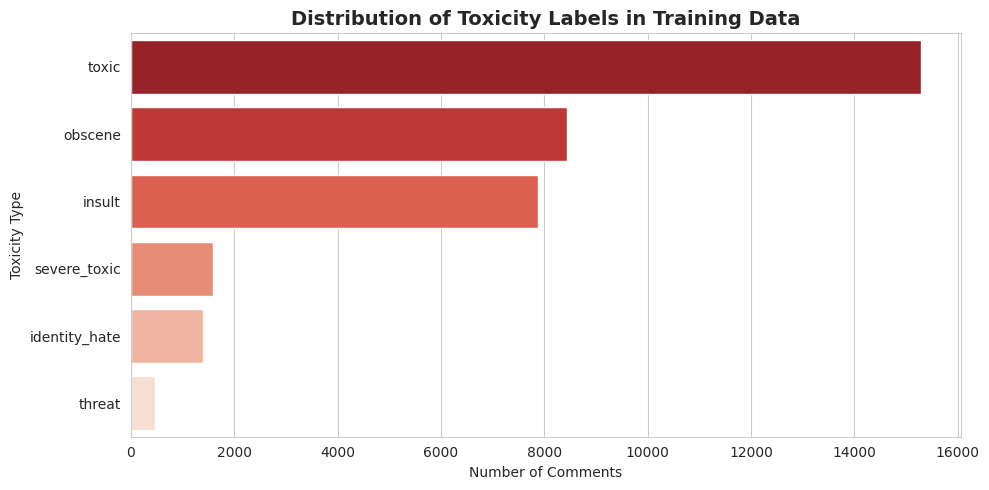

Clean comments (no toxicity): 143346 (89.83%)


In [7]:
# Define label columns (excluding 'id' and 'comment_text')
label_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# Count of each label
label_counts = train_df[label_cols].sum().sort_values(ascending=False)

# Plot 1: Bar chart of label frequencies
plt.figure(figsize=(10,5))
sns.barplot(x=label_counts.values, y=label_counts.index, palette='Reds_r')
plt.title('Distribution of Toxicity Labels in Training Data', fontsize=14, fontweight='bold')
plt.xlabel('Number of Comments')
plt.ylabel('Toxicity Type')
plt.tight_layout()
plt.show()

# Percentage of comments that are completely clean (no label = 1)
clean_comments = (train_df[label_cols].sum(axis=1) == 0).sum()
print(f"Clean comments (no toxicity): {clean_comments} ({clean_comments/len(train_df)*100:.2f}%)")

### Multi-label correlation heatmap

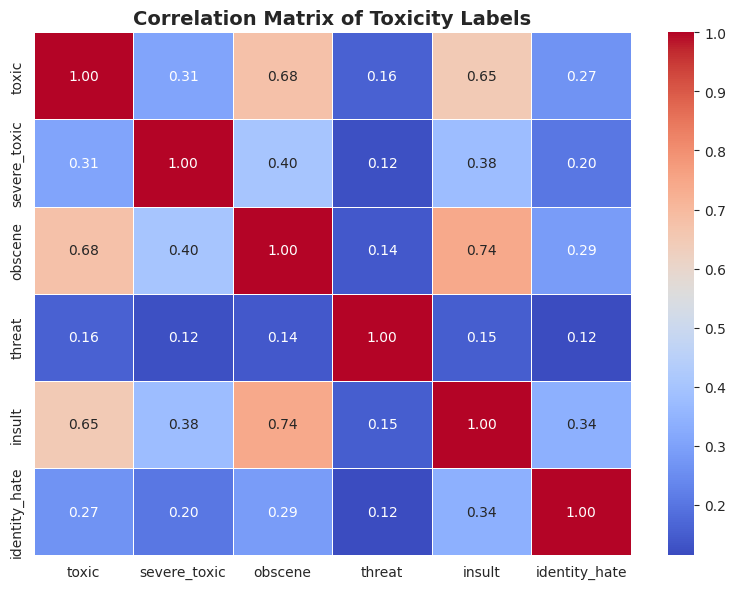

In [8]:
# Correlation between labels
plt.figure(figsize=(8,6))
corr = train_df[label_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Toxicity Labels', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Word cloud for toxic vs. non-toxic comments

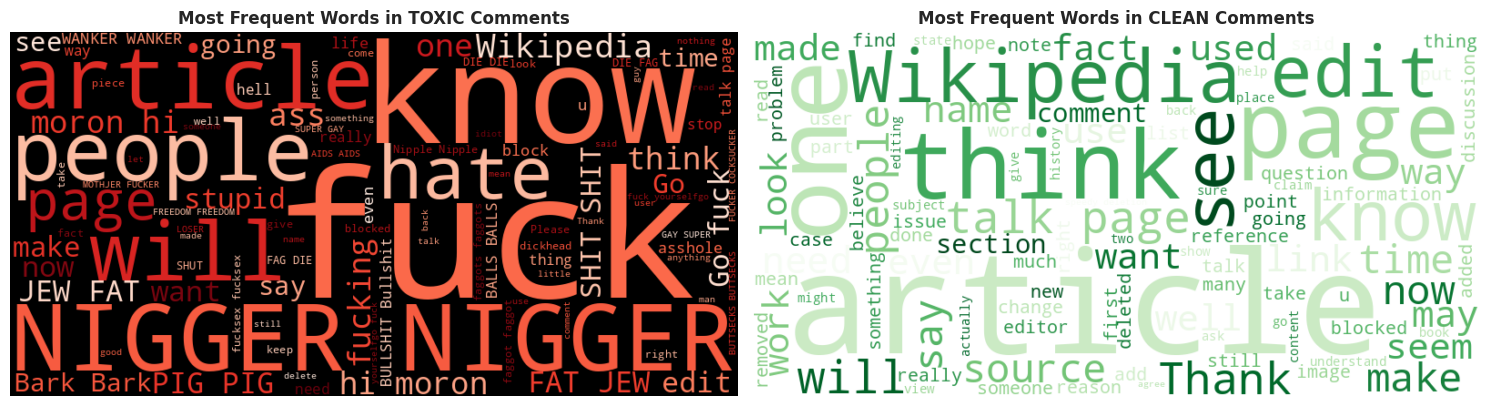

In [9]:
# Separate comments into toxic (any label = 1) and non-toxic
toxic_mask = train_df[label_cols].sum(axis=1) > 0
toxic_comments = ' '.join(train_df[toxic_mask]['comment_text'].astype(str))
clean_comments_text = ' '.join(train_df[~toxic_mask]['comment_text'].astype(str))

# Generate word clouds
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
wordcloud_toxic = WordCloud(width=800, height=400, background_color='black', colormap='Reds',
                            max_words=100, contour_width=1).generate(toxic_comments)
wordcloud_clean = WordCloud(width=800, height=400, background_color='white', colormap='Greens',
                            max_words=100, contour_width=1).generate(clean_comments_text)

axes[0].imshow(wordcloud_toxic, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Most Frequent Words in TOXIC Comments', fontsize=12, fontweight='bold')

axes[1].imshow(wordcloud_clean, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Most Frequent Words in CLEAN Comments', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### Text preprocessing function

In [10]:
def clean_text(text):
    """Basic text cleaning for toxicity classification"""
    if isinstance(text, str):
        text = text.lower()
        text = re.sub(r'http\S+', '', text)          # remove URLs
        text = re.sub(r'[^a-z\s]', '', text)         # remove special characters & numbers
        text = re.sub(r'\s+', ' ', text).strip()     # extra spaces
        return text
    else:
        return ""

# Apply cleaning to training comments
train_df['cleaned_text'] = train_df['comment_text'].apply(clean_text)
print("Cleaning done. Example:")
print(train_df['cleaned_text'].iloc[0][:200])

Cleaning done. Example:
explanation why the edits made under my username hardcore metallica fan were reverted they werent vandalisms just closure on some gas after i voted at new york dolls fac and please dont remove the tem


### Feature extraction (TF‑IDF)

In [11]:
# Use only 10,000 features to keep memory and time reasonable in Colab
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2), stop_words='english')
X_train = vectorizer.fit_transform(train_df['cleaned_text'])
y_train = train_df[label_cols].values

print(f"TF-IDF matrix shape: {X_train.shape}")

TF-IDF matrix shape: (159571, 10000)


### Train multi-label logistic regression model

In [12]:
# MultiOutputClassifier wraps a binary classifier for each label
base_lr = LogisticRegression(solver='liblinear', max_iter=500, class_weight='balanced')
model = MultiOutputClassifier(base_lr, n_jobs=-1)

print("Training started... (this may take 2-3 minutes)")
model.fit(X_train, y_train)
print("Training completed.")

Training started... (this may take 2-3 minutes)
Training completed.


### Save model, vectorizer, and label columns locally & to Drive

In [13]:
# Save locally
joblib.dump(model, 'toxic_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')
joblib.dump(label_cols, 'label_columns.pkl')
print("Model, vectorizer and labels saved locally.")

# Also save to Google Drive (optional but recommended)
drive_path = '/content/drive/MyDrive/Project6_Jigsaw_Model/'
os.makedirs(drive_path, exist_ok=True)
joblib.dump(model, drive_path + 'toxic_model.pkl')
joblib.dump(vectorizer, drive_path + 'tfidf_vectorizer.pkl')
joblib.dump(label_cols, drive_path + 'label_columns.pkl')
print(f"Also saved to Drive: {drive_path}")

Model, vectorizer and labels saved locally.
Also saved to Drive: /content/drive/MyDrive/Project6_Jigsaw_Model/


### Load test data and true labels

In [14]:
# Load test data (comment text)
test_df = pd.read_csv('test.csv')
# Load true labels for test set
test_labels_df = pd.read_csv('test_labels.csv')

print(f"Test set shape: {test_df.shape}")
print(f"Test labels shape: {test_labels_df.shape}")

# Merge to align rows
test_df = test_df.merge(test_labels_df, on='id', how='left')
print(f"After merge: {test_df.shape}")

# Remove samples that have -1 (meaning 'not used for evaluation') – required by Jigsaw
test_df = test_df[~((test_df[label_cols] == -1).any(axis=1))]
print(f"After removing -1 samples: {test_df.shape}")

Test set shape: (153164, 2)
Test labels shape: (153164, 7)
After merge: (153164, 8)
After removing -1 samples: (63978, 8)


### Prepare test features

In [15]:
# Clean test comments
test_df['cleaned_text'] = test_df['comment_text'].apply(clean_text)
X_test = vectorizer.transform(test_df['cleaned_text'])
y_test = test_df[label_cols].values

print(f"Test TF-IDF shape: {X_test.shape}")

Test TF-IDF shape: (63978, 10000)


### Predict probabilities & evaluate

In [16]:
# Predict probabilities (for ROC-AUC)
y_pred_proba = model.predict_proba(X_test)
# Each element in y_pred_proba is an array of shape (n_samples,2) for one label.
# Extract probability of class 1 (toxic) for each label.
y_pred_proba_positive = np.array([proba[:,1] for proba in y_pred_proba]).T

# Compute ROC-AUC per label
auc_scores = {}
for i, col in enumerate(label_cols):
    auc = roc_auc_score(y_test[:, i], y_pred_proba_positive[:, i])
    auc_scores[col] = auc

# Display AUCs
print("ROC-AUC Score per label:")
for label, auc in auc_scores.items():
    print(f"  {label:15s} : {auc:.4f}")
print(f"\nAverage ROC-AUC: {np.mean(list(auc_scores.values())):.4f}")

ROC-AUC Score per label:
  toxic           : 0.9511
  severe_toxic    : 0.9802
  obscene         : 0.9666
  threat          : 0.9790
  insult          : 0.9602
  identity_hate   : 0.9708

Average ROC-AUC: 0.9680


### Visualisation: ROC curves for all labels

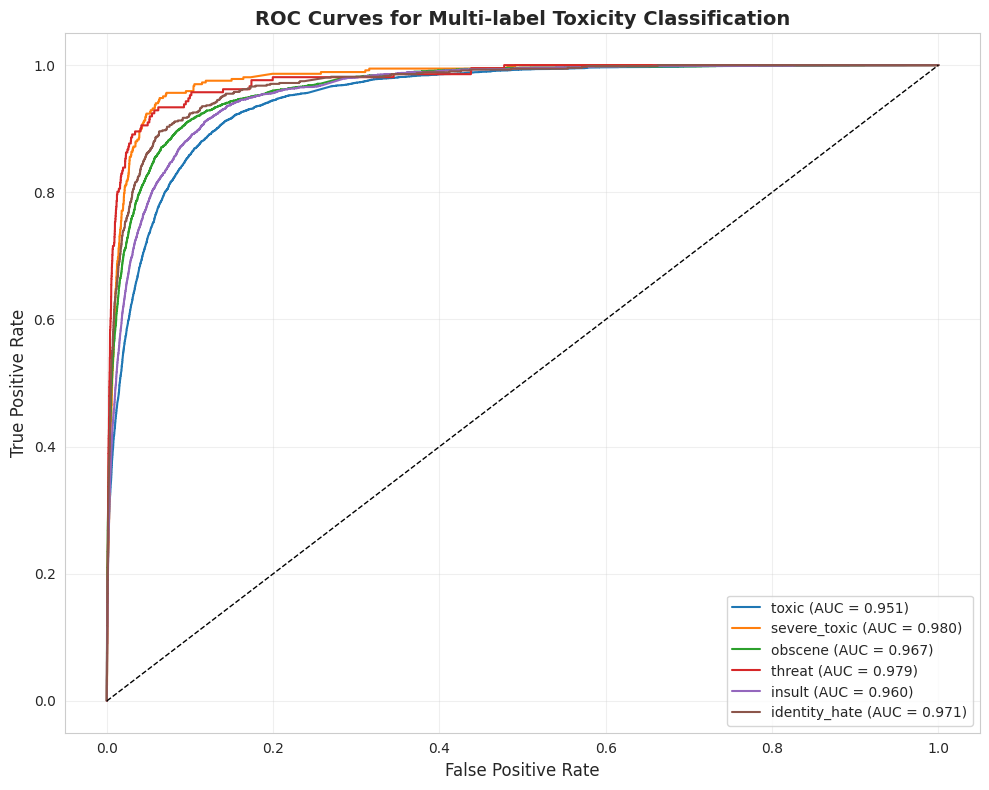

In [17]:
plt.figure(figsize=(10,8))
for i, col in enumerate(label_cols):
    fpr, tpr, _ = roc_curve(y_test[:, i], y_pred_proba_positive[:, i])
    plt.plot(fpr, tpr, label=f'{col} (AUC = {auc_scores[col]:.3f})')

plt.plot([0,1], [0,1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves for Multi‑label Toxicity Classification', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Confusion matrices for a few labels (using threshold 0.5)

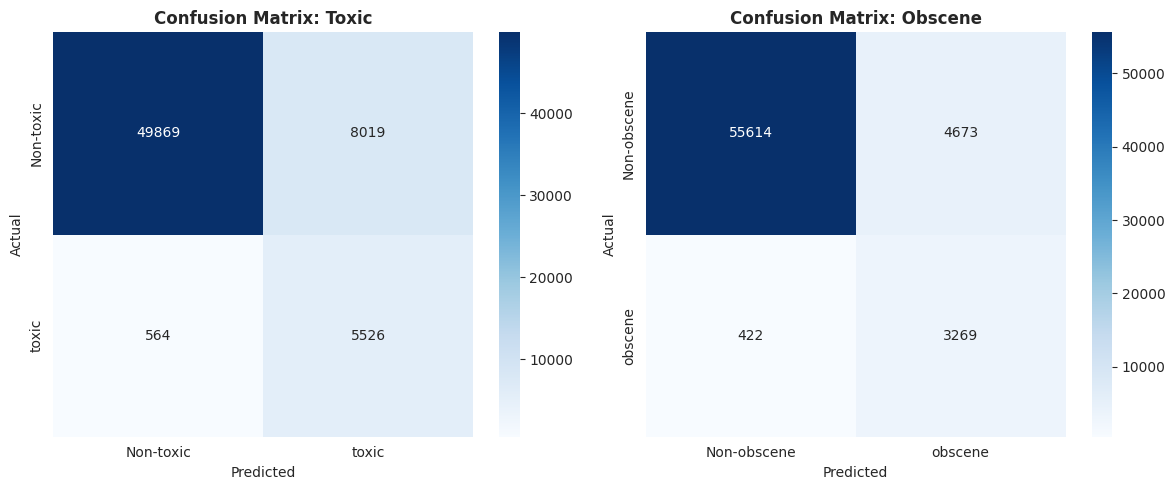

In [18]:
# Convert probabilities to binary predictions at 0.5 threshold
y_pred_binary = (y_pred_proba_positive >= 0.5).astype(int)

# Plot confusion matrices for 'toxic' and 'obscene' (most frequent)
fig, axes = plt.subplots(1, 2, figsize=(12,5))
for idx, label in enumerate(['toxic', 'obscene']):
    cm = confusion_matrix(y_test[:, label_cols.index(label)], y_pred_binary[:, label_cols.index(label)])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Non-'+label, label], yticklabels=['Non-'+label, label])
    axes[idx].set_title(f'Confusion Matrix: {label.capitalize()}', fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()

### Classification report (detailed metrics per label)

In [19]:
print("\n===== Detailed Classification Report (threshold=0.5) =====")
for i, col in enumerate(label_cols):
    print(f"\n--- {col.upper()} ---")
    print(classification_report(y_test[:, i], y_pred_binary[:, i], zero_division=0))


===== Detailed Classification Report (threshold=0.5) =====

--- TOXIC ---
              precision    recall  f1-score   support

           0       0.99      0.86      0.92     57888
           1       0.41      0.91      0.56      6090

    accuracy                           0.87     63978
   macro avg       0.70      0.88      0.74     63978
weighted avg       0.93      0.87      0.89     63978


--- SEVERE_TOXIC ---
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     63611
           1       0.11      0.91      0.19       367

    accuracy                           0.96     63978
   macro avg       0.55      0.93      0.59     63978
weighted avg       0.99      0.96      0.97     63978


--- OBSCENE ---
              precision    recall  f1-score   support

           0       0.99      0.92      0.96     60287
           1       0.41      0.89      0.56      3691

    accuracy                           0.92     63978
   macro avg  

### Final summary

In [21]:
print("\n" + "="*50)
print("Jigsaw Toxic Comment Classifier - COMPLETED")
print("Author: Ibrahim")
print("="*50)
print(f"Training samples: {len(train_df)}")
print(f"Test samples (evaluated): {len(test_df)}")
print(f"Model: Logistic Regression with TF-IDF (10k features)")
print(f"Average ROC-AUC on test set: {np.mean(list(auc_scores.values())):.4f}")
print("\nSaved files:")
print(" - toxic_model.pkl")
print(" - tfidf_vectorizer.pkl")
print(" - label_columns.pkl")
print(" - submission.csv")
print("\nAll visualizations displayed above. Ready for deployment or further tuning.")


Jigsaw Toxic Comment Classifier - COMPLETED
Author: Ibrahim
Training samples: 159571
Test samples (evaluated): 63978
Model: Logistic Regression with TF-IDF (10k features)
Average ROC-AUC on test set: 0.9680

Saved files:
 - toxic_model.pkl
 - tfidf_vectorizer.pkl
 - label_columns.pkl
 - submission.csv

All visualizations displayed above. Ready for deployment or further tuning.
